# KernelGap Synthetic Dataset

In [3]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import KernelGap_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

In [4]:
# ── 1. Data Import ────────────────────────────────────────────────────────────
# Labels come from the leading eigenvector of a fixed, entangling quantum
# kernel (reps=2 -> classically harder to simulate). A classical RBF kernel
# has a very different eigenstructure, so it should struggle where the
# quantum kernel (built from the very same feature map) will not.
X, y = KernelGap_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

print(f"Dataset  : KernelGap Synthetic, 20 per class")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

RESULTS_DIR = 'Results/KernelGap Synthetic'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

Dataset  : KernelGap Synthetic, 20 per class
Train    : (28, 4)  |  Test: (12, 4)


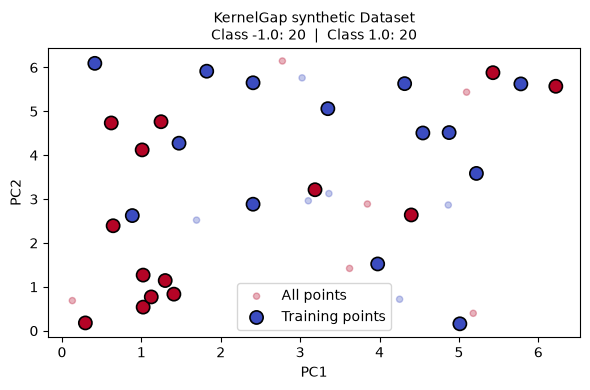

In [5]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('KernelGap synthetic', X, y, X_train, y_train, 'yes')

In [ ]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric' or 'haar'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    # Dataset is small (40 points) -> no subsetting needed, train on all of it.
    ExperimentConfig(
        name             = 'optuna',
        optimizer        = 'optuna',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'mealpy',
        optimizer        = 'mealpy',
        variant          = 'geometric',
        subset_method    = 'none',
        subset_kwargs    = {},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

In [7]:
# ── 4. Run ─────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.

summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)

summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))

    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)

    results = get_svm_results(config, K_train, y_sub, K_test, y_test)

    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-20 14:28:49,523] A new study created in memory with name: no-name-5d149544-8f4b-4e0c-858f-b39cb9aaba07


Saved SVM        → Results/KernelGap Synthetic/Classical_baseline/svm.pkl

REPORT: Classical_baseline
Best C            : 0.1
Best CV accuracy  : 0.7000
Test accuracy     : 0.5833
              precision    recall  f1-score   support

        -1.0       0.57      0.67      0.62         6
         1.0       0.60      0.50      0.55         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12


────────────────────────────────────────────────────────────
 optuna  [optuna + none]
────────────────────────────────────────────────────────────


[I 2026-08-20 14:28:51,849] Trial 0 finished with value: 10.613614447298689 and parameters: {'gate_0': 'RX', 'angle_0': 3.9520848551269947, 'gate_1': 'I', 'angle_1': 1.1026367147333214, 'gate_2': 'RZ', 'angle_2': 0.3605875018966864, 'gate_3': 'I', 'angle_3': 2.897522041587758, 'gate_4': 'I', 'angle_4': 1.0447059571434598, 'gate_5': 'RY', 'angle_5': 3.8357342858146217, 'gate_6': 'I', 'angle_6': 5.256004232772834, 'gate_7': 'CNOT', 'angle_7': 0.9948058593459569, 'gate_8': 'RZ', 'angle_8': 1.1664400577562957, 'gate_9': 'I', 'angle_9': 5.287617158406563, 'gate_10': 'CNOT', 'angle_10': 0.9865571661062207, 'gate_11': 'H', 'angle_11': 0.4191053291344407, 'gate_12': 'RX', 'angle_12': 1.4067694892476732, 'gate_13': 'RY', 'angle_13': 1.2280552845825246, 'gate_14': 'RZ', 'angle_14': 4.611532058876675, 'gate_15': 'RX', 'angle_15': 1.4060291340208622}. Best is trial 0 with value: 10.613614447298689.
[I 2026-08-20 14:28:54,015] Trial 1 finished with value: 9.889914293506878 and parameters: {'gate_0'

Saved candidate  → Results/KernelGap Synthetic/optuna/candidate.pkl
Computing cross-kernel (test × subset)…


2026/08/20 02:33:11 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=30, pop_size=20, pc=0.95, pm=0.1)


Saved SVM        → Results/KernelGap Synthetic/optuna/svm.pkl

REPORT: optuna | 100 trials
Best C            : 10
Best CV accuracy  : 0.6500
Test accuracy     : 0.5833
              precision    recall  f1-score   support

        -1.0       0.57      0.67      0.62         6
         1.0       0.60      0.50      0.55         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12


────────────────────────────────────────────────────────────
 mealpy  [mealpy + none]
────────────────────────────────────────────────────────────


2026/08/20 02:34:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 10.597679485407406, Global best: 10.597679485407406, Runtime: 45.03422 seconds
2026/08/20 02:35:31 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 10.597679485407406, Global best: 10.597679485407406, Runtime: 43.06393 seconds
2026/08/20 02:36:08 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 9.913397795940739, Global best: 10.597679485407406, Runtime: 36.64362 seconds
2026/08/20 02:36:45 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 10.720434297528703, Global best: 10.720434297528703, Runtime: 37.21402 seconds
2026/08/20 02:37:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 11.042375331762322, Global best: 11.042375331762322, Runtime: 39.04301 seconds
2026/08/20 02:37:59 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Proble

Saved candidate  → Results/KernelGap Synthetic/mealpy/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/KernelGap Synthetic/mealpy/svm.pkl

REPORT: mealpy | 30 epochs | 20 pop | 0.1 pm
Best C            : 0.1
Best CV accuracy  : 0.4833
Test accuracy     : 0.5000
              precision    recall  f1-score   support

        -1.0       0.50      0.67      0.57         6
         1.0       0.50      0.33      0.40         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.49        12
weighted avg       0.50      0.50      0.49        12



In [8]:
# ── 5. Summary table ───────────────────────────────────────────────────────

def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 75}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 75}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 75}\n")

print_summary(summary)


═══════════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
───────────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.5833    0.7000         —    0.1
  optuna                              0.5833    0.6500     11.81     10
  mealpy                              0.5000    0.4833     12.50    0.1
═══════════════════════════════════════════════════════════════════════════



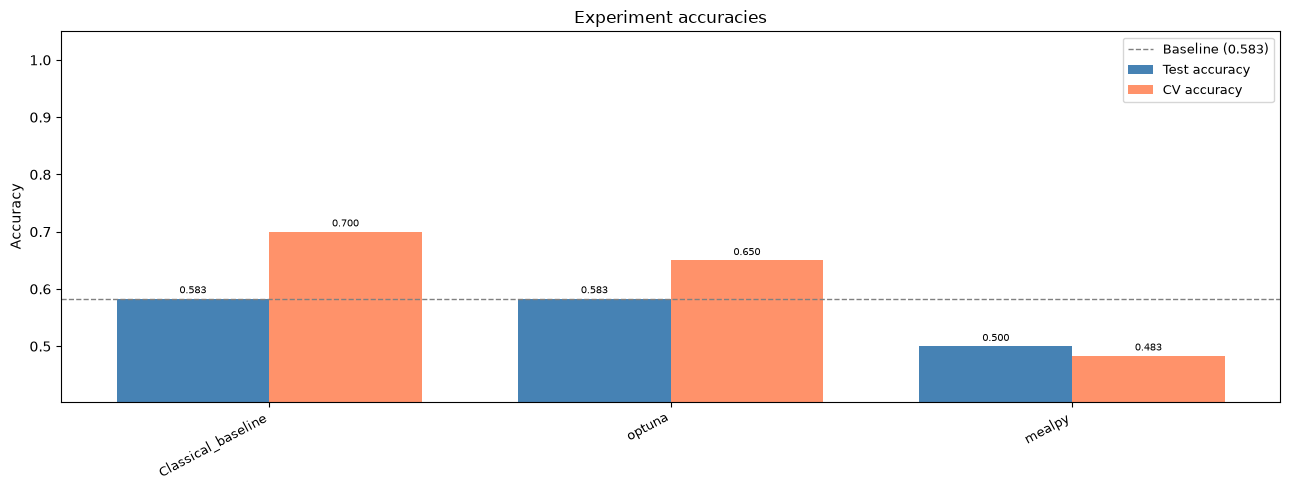

Saved → Results/KernelGap Synthetic/accuracy_comparison.png


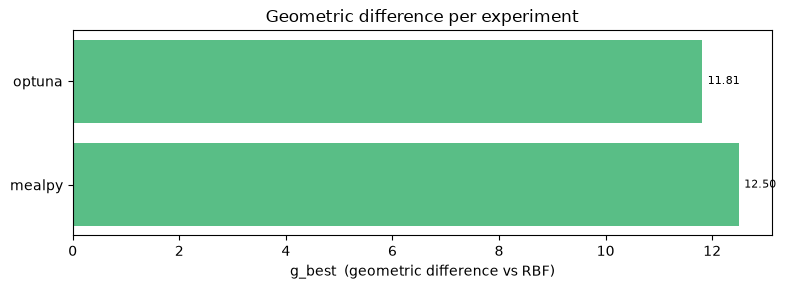

Saved → Results/KernelGap Synthetic/g_best_comparison.png


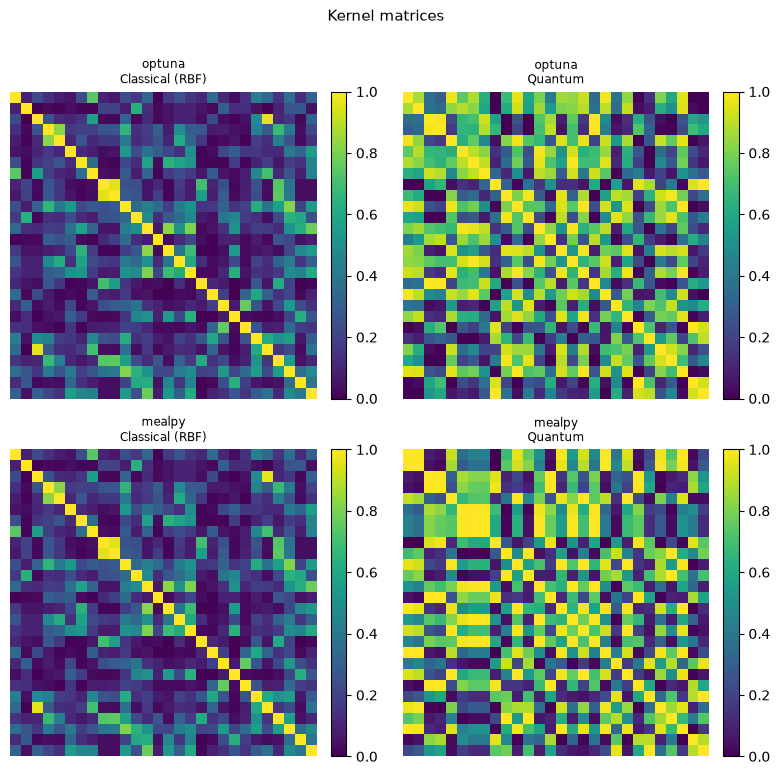

Saved → Results/KernelGap Synthetic/kernel_heatmaps.png


In [9]:
# ── 6. Visualizations ──────────────────────────────────────────────────────
plot_accuracy(summary, ['test', 'CV'])
plot_g_best(summary)
plot_kernel_heatmaps(summary)